# Summary of the challenge

To build an agent router that connects to the corresponding agent depending on user query.
Also, priority router will be implemented to ensure more correspondance 

### Workflow:

Router -> Agent -> Another Router

### Built With:
- Conditional routing
- Multiple routers
- State accumulation
- Hybrid deterministic + LLM decision making
- Separate responsibility per node

In [214]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from openai import OpenAI
from dotenv import load_dotenv

In [215]:
load_dotenv()

True

In [216]:
GPT_5_4 = "gpt-5.4-2026-03-05"
GPT_5_4_MINI = "gpt-5.4-mini-2026-03-17"

In [217]:
class State(TypedDict):
    query: str
    priority_score: int
    priority_decision: str
    result: str # used as a result for routing decision

In [218]:
class Llm: 
    def __init__(self, model):
        self.model = model
        self.client = None

    def initiate_llm(self):
        self.client = OpenAI()

    def decide_agent(self, query): 
        if self.client is None:
            self.initiate_llm()

        response = self.client.responses.create(
            model=self.model,
            input=f"""
            Analyze the user query and response in string either "coding" 
            or "general" without any additional comments or text.
            This is supposed to return structured output in string for the use of 
            intent router (coding agent or general agent). 
            You should return most corresponding or likely response 
            based on the type of user query after you analyze it.

            RULES:
            1. return "coding" when: the query contains anything about coding, programming, 
            programming languages, or any technical questions in software development.

            2. Return "general" when: Anything rather than the programming topic.

            Down below is the user query:
            {query}
            """.strip()
        )

        return response.output_text


    def decide_priority(self, query, priority_score):
        if self.client is None:
            self.initiate_llm()
            
        response = self.client.responses.create(
            model=self.model,
            input=f"""
            Based on query, try to detect the urgency of the task and return strcutured output.

            RULES:
            1. Return string "urgent" when you feel that the query gives off a sense of urgency.
            e.g. "I have to finish this task by tomorrow! or "The deadline is by the afternoon today"
            or "This is an important task that should be completed as soon as possible" or anything similar vibes or user intent given off.

            2. Return string "normal" when you think the query doesn't sound like urgency or it just sounds
            typical routine job or any general questions.
            e.g. "What is Python?" or "How do I build the basic CRUD?" or "Build the basic bolilerplate CSS code for me"

            3. Also consider this keyword score: {priority_score} and higher 
            the number it is, it will affect your decision leaning onto returning "urgency"

            FORMAT:
            just a string for example, "urgent" or "normal"
            Down below is the user query:
            {query}
            """
        )

        print("URGENCY LLM RESPONSE: ", response.output_text)
        return response.output_text

In [219]:
def coding_agent(state):
    return {"result": "Coding agent selected"}

In [220]:
def general_agent(state):
    return {"result": "General agent selected"}

In [221]:
def intent_router(state):
    llm = Llm(GPT_5_4_MINI)
    intent = llm.decide_agent(state["query"])

    if intent == "coding":
        print("CODING AGENT SELECTED")
        return "coding"
    else:
        print("GENERAL AGENT SELECTED")
        return "general"    

In [222]:
def urgent_queue_agent(state): 
    return {"result": "URGENT queue agent selected"}

In [223]:
def normal_queue_agent(state): 
    return {"result": "NORMAL queue agent selected"}

In [224]:
def priority_score_agent(state): 
    query = state["query"] 
    weight_sum = 0
    
    urgency_keywords = {
        "urgent": 3,
        "asap": 3,
        "immediately": 3,
        "critical": 4,
        "emergency": 5,
        "production": 4,
        "prod": 4,
        "outage": 5,
        "system down": 5,
        "deadline": 3,
        "today": 2,
        "blocked": 3,
        "customer impact": 4,
    }
    
    for k, v in urgency_keywords.items():
        if k in query:
            weight_sum += v

    print("WEIGHT: ", weight_sum)

    return {"priority_score": weight_sum}

In [225]:
def priority_decision_agent(state):
    llm = Llm(GPT_5_4_MINI)
    result = llm.decide_priority(
        query=state["query"],
        priority_score=state["priority_score"]
    )

    if result == "urgent": 
        return {"priority_decision": "urgent"}
    else:
        return {"priority_decision": "normal"}

In [226]:
def priority_router(state):
    priority = state["priority_decision"]
    
    if priority == "urgent":
        print("URGENCY QUEUE SELECTED")
        return "urgent"
    else:
        print("NORMAL QUEUE SELECTED")
        return "normal"

In [227]:
builder = StateGraph(State)

builder.add_node("coding_agent", coding_agent) 
builder.add_node("general_agent", general_agent)
builder.add_node("intent_router", lambda state: state)
builder.add_node("urgent_queue_agent", urgent_queue_agent)
builder.add_node("normal_queue_agent", normal_queue_agent) 
builder.add_node("priority_score_agent", priority_score_agent)
builder.add_node("priority_decision_agent", priority_decision_agent)
builder.add_node("priority_router", lambda state: state)

builder.add_edge(START, "intent_router")
builder.add_conditional_edges(
    "intent_router",
    intent_router,
    {
        "coding": "coding_agent",
        "general": "general_agent"
    }
)
builder.add_edge("coding_agent", "priority_score_agent") 
builder.add_edge("priority_score_agent", "priority_decision_agent")
builder.add_edge("priority_decision_agent", "priority_router")
builder.add_conditional_edges(
    "priority_router",
    priority_router,
    {
        "urgent": "urgent_queue_agent",
        "normal": "normal_queue_agent"
    }
)
builder.add_edge("urgent_queue_agent", END) 
builder.add_edge("normal_queue_agent", END)
builder.add_edge("general_agent", END)

graph = builder.compile()

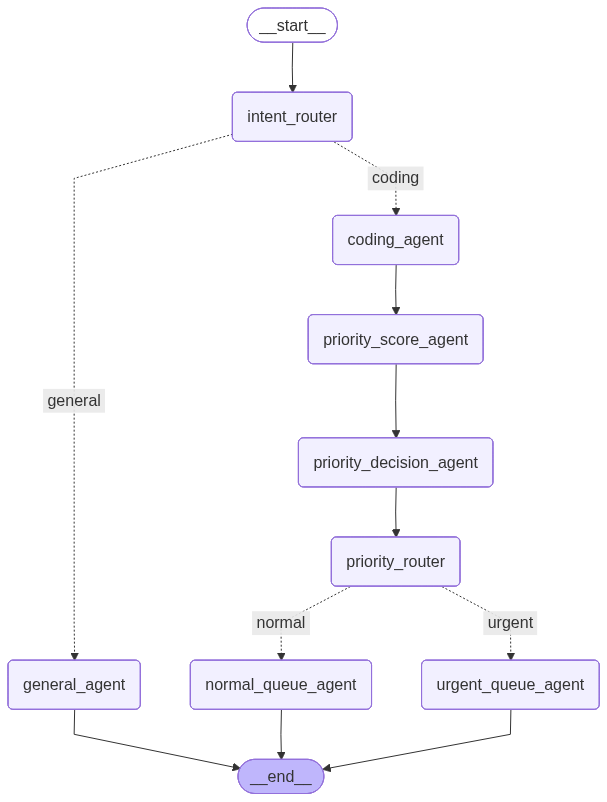

In [228]:
builder.compile()

In [231]:
graph.invoke({
    "query": "Build the CRUD in FastAPI. I have to get it done in 2 hours! This is an urgent task!"
})

CODING AGENT SELECTED
WEIGHT:  3
URGENCY LLM RESPONSE:  urgent
URGENCY QUEUE SELECTED


{'query': 'Build the CRUD in FastAPI. I have to get it done in 2 hours! This is an urgent task!',
 'priority_score': 3,
 'priority_decision': 'urgent',
 'result': 'URGENT queue agent selected'}